In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

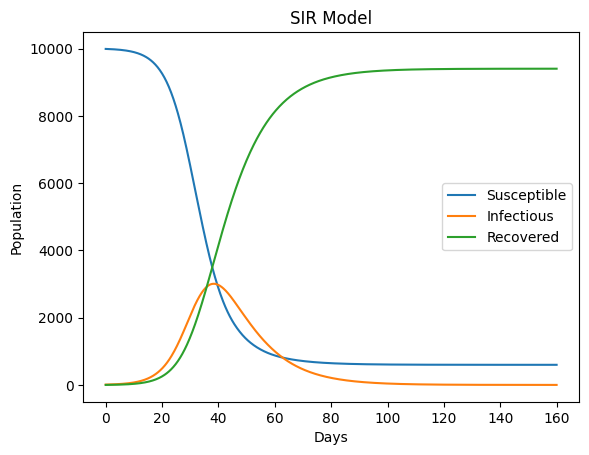

In [3]:
def sir(t, y, N=10000, beta=0.3, gamma=0.1):
    S, I, R = y
    dS = -beta * S * I / N
    dI =  beta * S * I / N - gamma * I
    dR =  gamma * I
    return [dS, dI, dR]

sol = solve_ivp(sir, [0, 160], [9990, 10, 0],
                t_eval=np.linspace(0, 160, 1000))

plt.plot(sol.t, sol.y[0], label='Susceptible')
plt.plot(sol.t, sol.y[1], label='Infectious')
plt.plot(sol.t, sol.y[2], label='Recovered')
plt.legend()
plt.xlabel('Days')
plt.ylabel('Population')
plt.title('SIR Model')
plt.show()

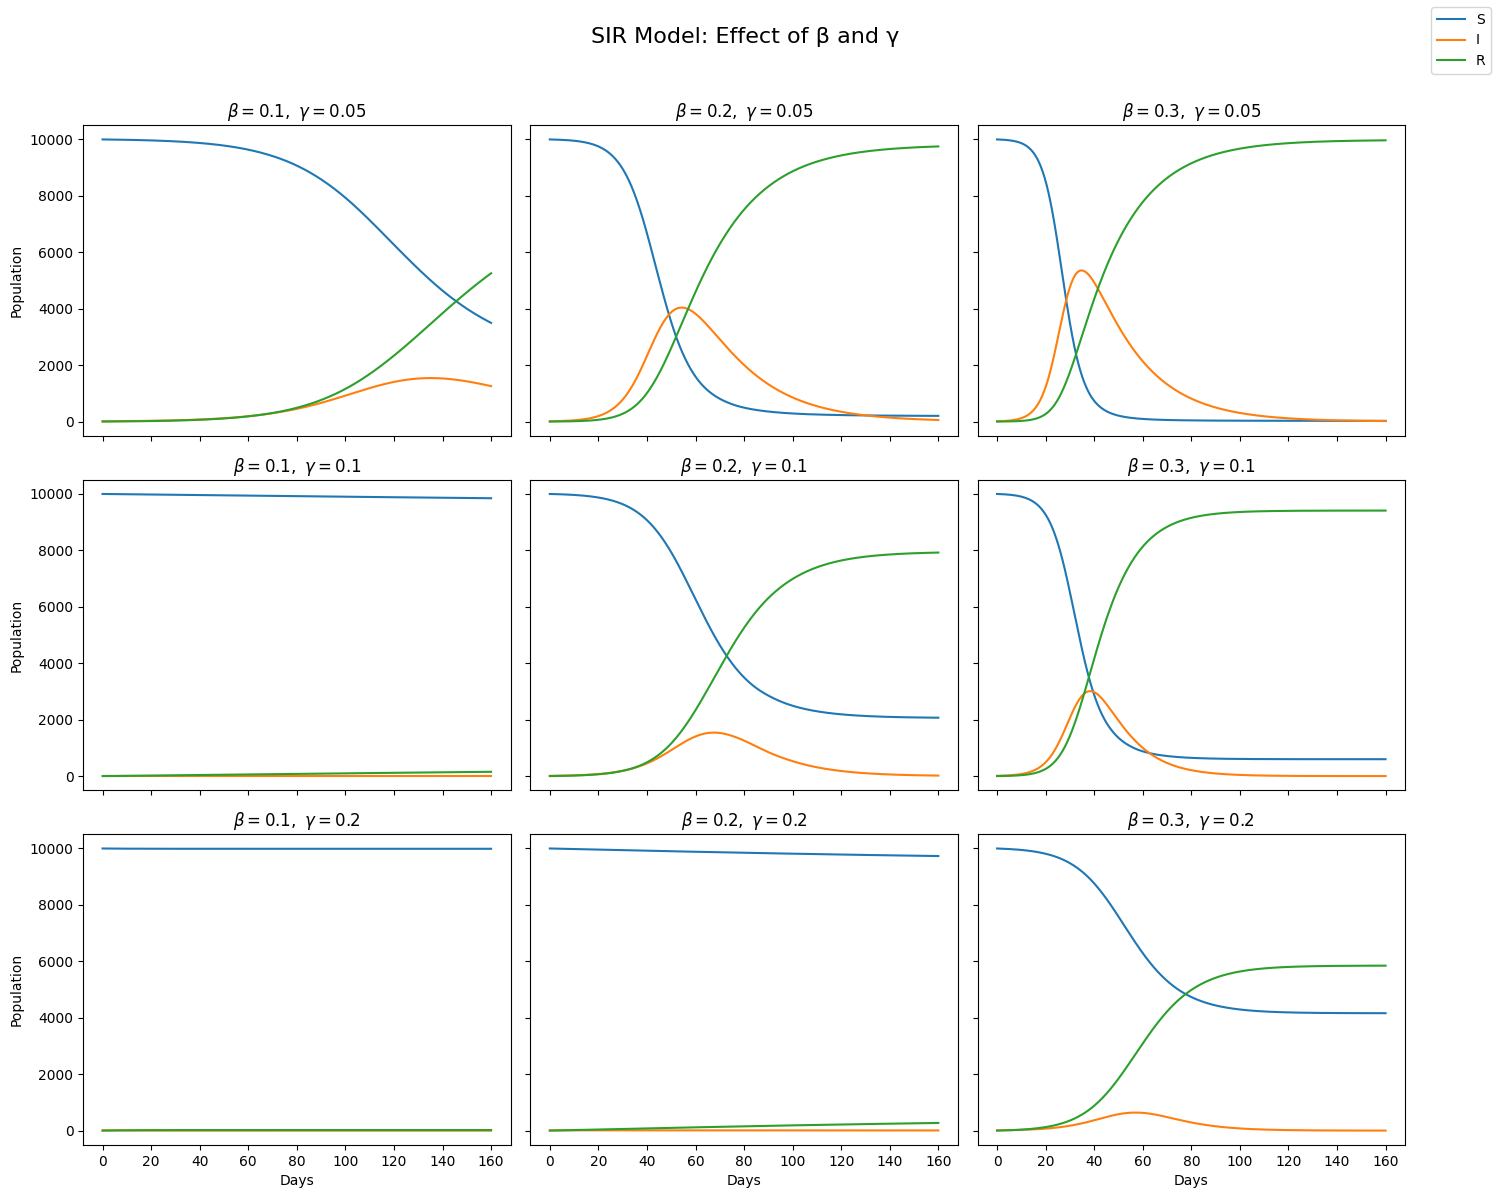

In [9]:
betas = [0.1, 0.2, 0.3]
gammas = [0.05, 0.1, 0.2]

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)

for row, gamma in enumerate(gammas):
    for col, beta in enumerate(betas):

        sol = solve_ivp(
            sir,
            [0, 160],
            [9990, 10, 0],
            args=(10000, beta, gamma),
            t_eval=np.linspace(0, 160, 1000)
        )

        ax = axes[row, col]

        ax.plot(sol.t, sol.y[0], label='S')
        ax.plot(sol.t, sol.y[1], label='I')
        ax.plot(sol.t, sol.y[2], label='R')

        ax.set_title(rf'$\beta={beta},\ \gamma={gamma}$')

        if row == 2:
            ax.set_xlabel('Days')
        if col == 0:
            ax.set_ylabel('Population')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

fig.suptitle('SIR Model: Effect of β and γ', fontsize=16)

plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()

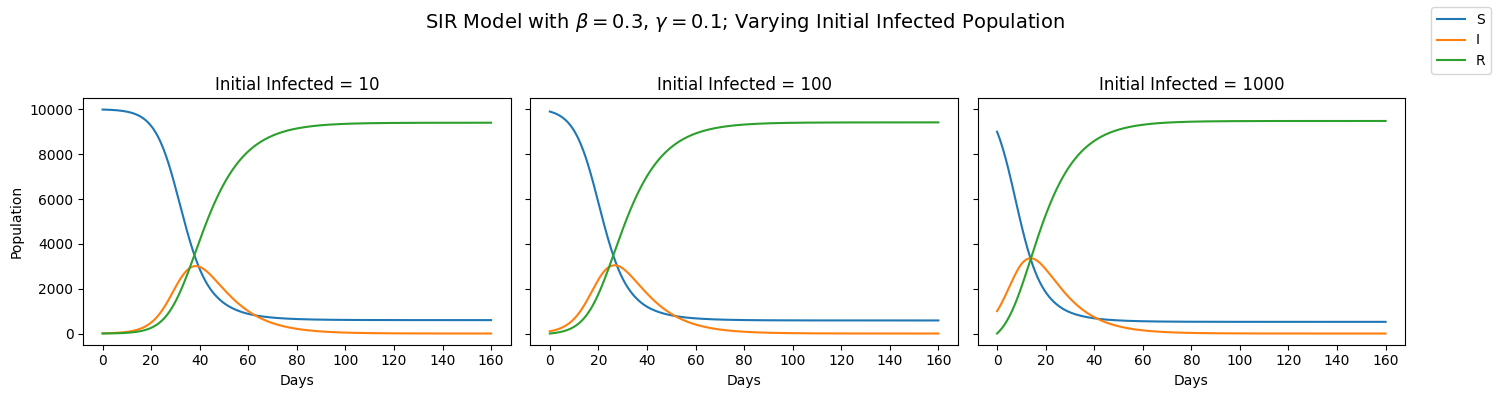

In [13]:
N = 10000
beta = 0.3
gamma = 0.1

initial_infected = [10, 100, 1000]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, I0 in zip(axes, initial_infected):

    S0 = N - I0
    R0 = 0

    sol = solve_ivp(
        sir,
        [0, 160],
        [S0, I0, R0],
        args=(N, beta, gamma),
        t_eval=np.linspace(0, 160, 1000)
    )

    ax.plot(sol.t, sol.y[0], label='S')
    ax.plot(sol.t, sol.y[1], label='I')
    ax.plot(sol.t, sol.y[2], label='R')

    ax.set_title(f'Initial Infected = {I0}')
    ax.set_xlabel('Days')

axes[0].set_ylabel('Population')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

fig.suptitle(
    rf'SIR Model with $\beta={beta}$, $\gamma={gamma}$; Varying Initial Infected Population',
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()

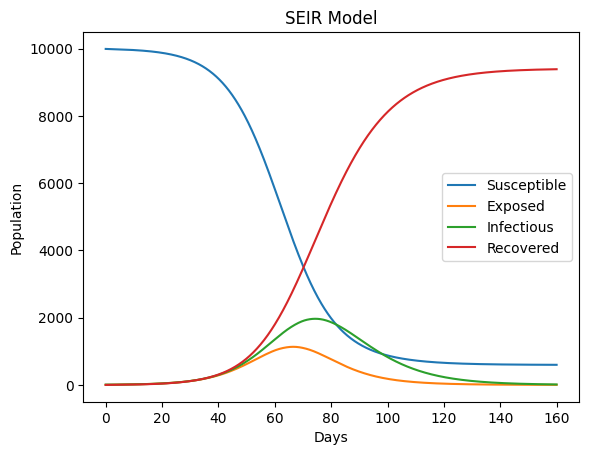

In [15]:
def seir(t, y, N=10000, beta=0.3, sigma=0.2, gamma=0.1):
    S, E, I, R = y

    dS = -beta * S * I / N
    dE = beta * S * I / N - sigma * E
    dI = sigma * E - gamma * I
    dR = gamma * I

    return [dS, dE, dI, dR]

sol = solve_ivp(seir, [0, 160], [9990, 0, 10, 0],
                t_eval=np.linspace(0, 160, 1000))

plt.plot(sol.t, sol.y[0], label='Susceptible')
plt.plot(sol.t, sol.y[1], label='Exposed')
plt.plot(sol.t, sol.y[2], label='Infectious')
plt.plot(sol.t, sol.y[3], label='Recovered')
plt.legend()
plt.xlabel('Days')
plt.ylabel('Population')
plt.title('SEIR Model')
plt.show()

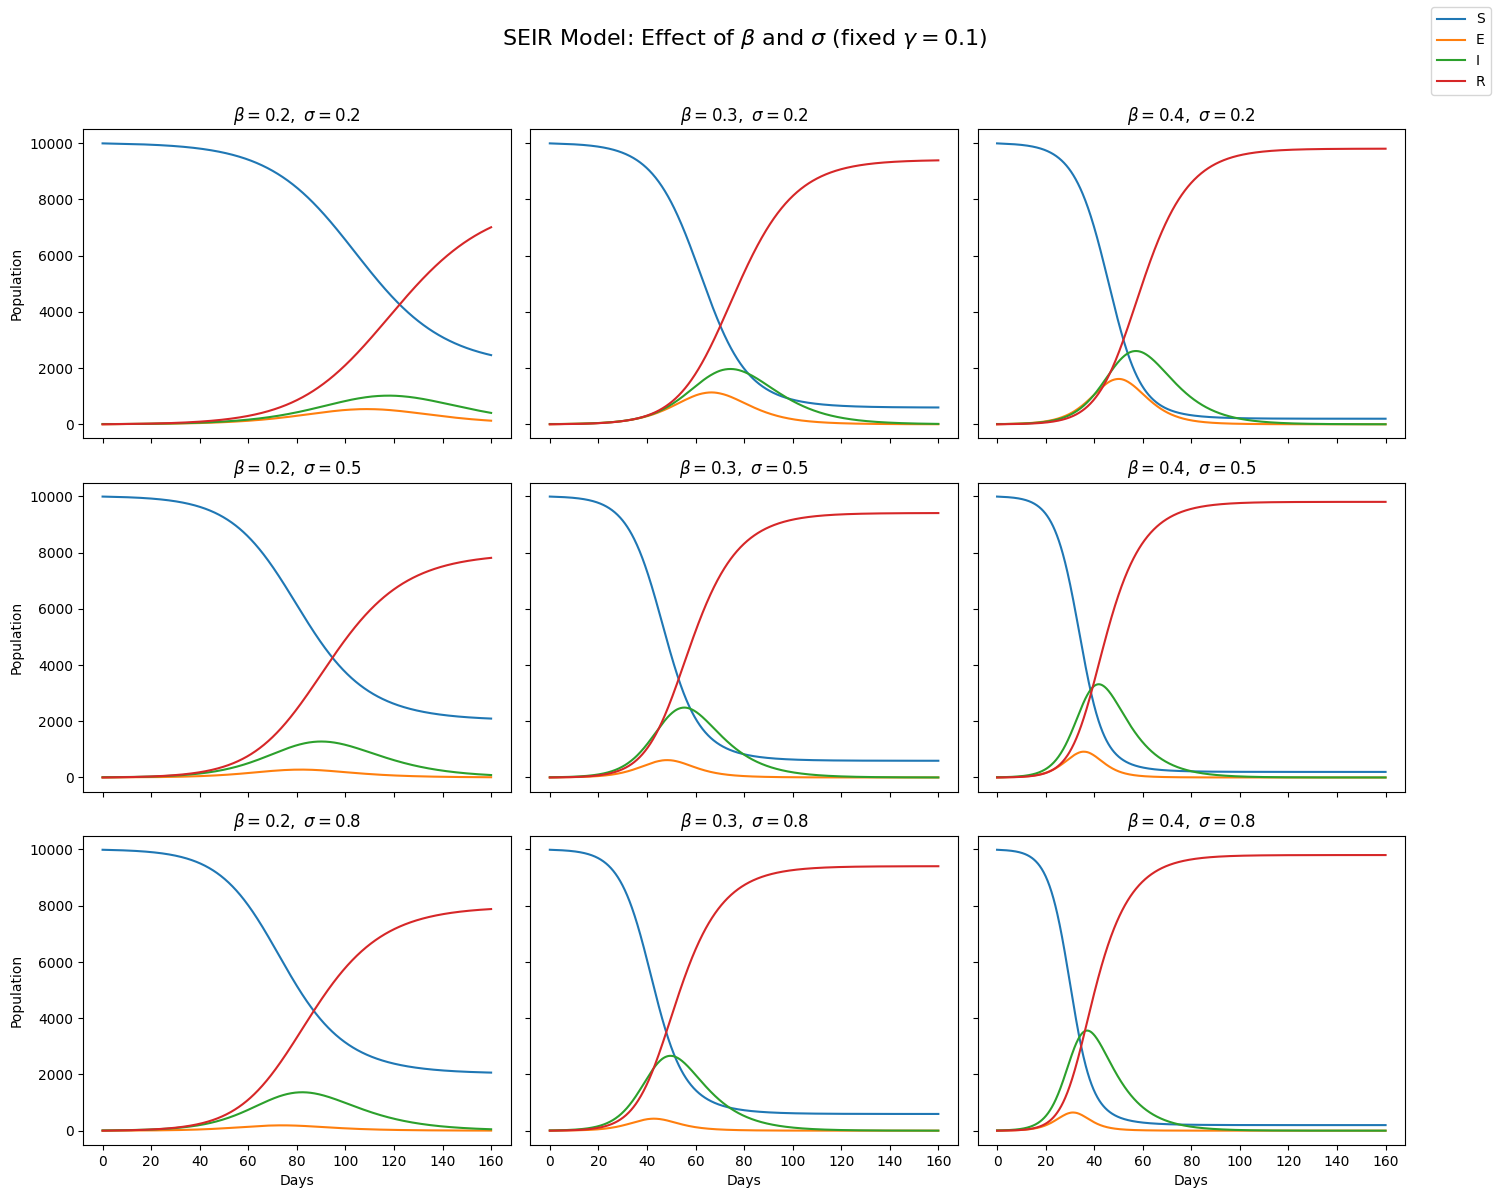

In [24]:
betas = [0.2, 0.3, 0.4]
sigmas = [0.2, 0.5, 0.8]

N = 10000
gamma = 0.1

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)

for row, sigma in enumerate(sigmas):
    for col, beta in enumerate(betas):

        sol = solve_ivp(
            seir,
            [0, 160],
            [9990, 0, 10, 0],  # S0, E0, I0, R0
            args=(N, beta, sigma, gamma),
            t_eval=np.linspace(0, 160, 1000)
        )

        ax = axes[row, col]

        ax.plot(sol.t, sol.y[0], label='S')
        ax.plot(sol.t, sol.y[1], label='E')
        ax.plot(sol.t, sol.y[2], label='I')
        ax.plot(sol.t, sol.y[3], label='R')

        ax.set_title(
            rf'$\beta={beta},\ \sigma={sigma}$'
        )

        if row == len(sigmas) - 1:
            ax.set_xlabel('Days')

        if col == 0:
            ax.set_ylabel('Population')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

fig.suptitle(
    rf'SEIR Model: Effect of $\beta$ and $\sigma$ (fixed $\gamma={gamma}$)',
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()